In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/bencarson/gemma-4-neutral-text-expansion/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-neutral-text-expansion/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-neutral-text-expansion/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-neutral-text-expansion/neutral_activations_expanded.npz
/kaggle/input/notebooks/bencarson/gemma-4-neutral-text-expansion/custom.css
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__huggingface_repos__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/custom.css
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
ACTS_PATH = '/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/activations.pkl'  # adjust
NRC_PATH  = '/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt'
LAYER     = 25

with open(ACTS_PATH, 'rb') as f:
    saved = pickle.load(f)

resid_acts = saved['resid']  # {emotion: [n_stories, n_layers, d_model]}

nrc = pd.read_csv(NRC_PATH, sep='\t', header=0,
                  names=['word', 'valence', 'arousal', 'dominance'])
nrc = nrc.drop_duplicates('word').set_index('word')


In [4]:
# ── Cell 3: Compute mean directions at layer 25 ──────────────────────────────
neutral_stories = resid_acts['__neutral__']        # [n_neutral, n_layers, d_model]
neutral_mean    = neutral_stories[:, LAYER, :].mean(axis=0)  # [d_model]

emotion_names, directions = [], []
for name, arr in resid_acts.items():
    if name == '__neutral__':
        continue
    mean_at_layer = arr[:, LAYER, :].mean(axis=0)  # [d_model]
    directions.append(mean_at_layer - neutral_mean)
    emotion_names.append(name)

directions = np.array(directions)  # [174, 1536]
print(f"Direction matrix: {directions.shape}")


Direction matrix: (174, 1536)


In [5]:
# ── Cell 4: Match to NRC-VAD ─────────────────────────────────────────────────
def lookup_vad(name):
    word = name.replace('_', ' ').lower()
    if word in nrc.index:
        return nrc.loc[word, ['valence', 'arousal', 'dominance']].values.astype(float)
    first = word.split()[0]
    if first in nrc.index:
        return nrc.loc[first, ['valence', 'arousal', 'dominance']].values.astype(float)
    return None

vad_rows, kept_names, kept_dirs, missing = [], [], [], []
for name, direction in zip(emotion_names, directions):
    row = lookup_vad(name)
    if row is not None:
        vad_rows.append(row)
        kept_names.append(name)
        kept_dirs.append(direction)
    else:
        missing.append(name)

if missing:
    print(f"No NRC entry for: {missing}")

vad  = np.array(vad_rows)   # [N, 3]  — valence, arousal, dominance
dirs = np.array(kept_dirs)  # [N, 1536]
print(f"Matched {len(kept_names)}/{len(emotion_names)} emotions")


No NRC entry for: ['energized', 'insulted', 'stimulated']
Matched 171/174 emotions


In [6]:
# ── Cell 5: PCA ──────────────────────────────────────────────────────────────
N_PCS = 50
pca    = PCA(n_components=N_PCS)
scores = pca.fit_transform(dirs)  # [N, 50]

cumvar = np.cumsum(pca.explained_variance_ratio_)
for k in [3, 5, 10, 16, 20, 36]:
    if k <= N_PCS:
        print(f"  {k:2d} PCs → {cumvar[k-1]*100:.1f}% variance")


   3 PCs → 52.4% variance
   5 PCs → 61.6% variance
  10 PCs → 73.7% variance
  16 PCs → 80.6% variance
  20 PCs → 83.6% variance
  36 PCs → 90.3% variance


In [7]:
# ── Cell 6: Per-PC correlation table — V, A, D ───────────────────────────────
dim_names = ['valence', 'arousal', 'dominance']
N_SHOW    = 20
rows = []
for i in range(N_SHOW):
    row = {'PC': i+1, 'var%': f"{pca.explained_variance_ratio_[i]*100:.1f}"}
    for j, dim in enumerate(dim_names):
        r, p = stats.pearsonr(scores[:, i], vad[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row[f'{dim}_r'] = f"{r:+.3f}{sig}"
    rows.append(row)

print(pd.DataFrame(rows).set_index('PC').to_string())

    var%  valence_r  arousal_r dominance_r
PC                                        
1   37.4  -0.403***   +0.206**   -0.328***
2    8.8  +0.378***     +0.029   +0.305***
3    6.3   +0.232**  -0.281***      -0.018
4    5.2  +0.457***     +0.134   +0.422***
5    4.0     +0.084     +0.088   +0.302***
6    3.3     +0.012  -0.475***     -0.175*
7    2.5   +0.223**     +0.078      +0.114
8    2.4     -0.082     -0.083    -0.224**
9    2.3    +0.185*   -0.228**      -0.075
10   1.7     -0.116     -0.122      -0.098
11   1.3     +0.020     -0.009      -0.062
12   1.3     +0.033     -0.112      +0.000
13   1.2     -0.011     +0.041      -0.060
14   1.1     -0.047     -0.069      -0.014
15   1.0     +0.148     -0.116      +0.092
16   0.9     -0.013    +0.157*      +0.103
17   0.9     -0.104   +0.234**      -0.033
18   0.8     -0.005     +0.047      -0.034
19   0.7     +0.134     +0.126      +0.103
20   0.7     +0.009     +0.008      -0.043


In [8]:
# ── Cell 7: Cumulative R² — which dimension is best explained? ───────────────
print(f"\n{'k':>4}  {'Valence R²':>11}  {'Arousal R²':>11}  {'Dominance R²':>13}  {'best':>8}")
for k in [1, 2, 3, 4, 5, 8, 10, 15, 20]:
    r2s = [
        sum(stats.pearsonr(scores[:, i], vad[:, j])[0]**2 for i in range(k))
        for j in range(3)
    ]
    best = dim_names[np.argmax(r2s)]
    print(f"{k:>4}  {r2s[0]:>11.3f}  {r2s[1]:>11.3f}  {r2s[2]:>13.3f}  {best:>8}")



   k   Valence R²   Arousal R²   Dominance R²      best
   1        0.163        0.042          0.107   valence
   2        0.305        0.043          0.201   valence
   3        0.359        0.122          0.201   valence
   4        0.568        0.140          0.379   valence
   5        0.576        0.148          0.470   valence
   8        0.632        0.386          0.563   valence
  10        0.679        0.453          0.579   valence
  15        0.705        0.485          0.595   valence
  20        0.734        0.583          0.620   valence


In [9]:
# ── Cell 8: What emotions drive each PC? ────────────────────────────────────
N_TOP = 6
for i in range(6):
    s = scores[:, i]
    pos = np.argsort(s)[-N_TOP:][::-1]
    neg = np.argsort(s)[:N_TOP]
    r_v, _ = stats.pearsonr(s, vad[:, 0])
    r_a, _ = stats.pearsonr(s, vad[:, 1])
    r_d, _ = stats.pearsonr(s, vad[:, 2])
    print(f"\nPC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}% var)  "
          f"V={r_v:+.3f}  A={r_a:+.3f}  D={r_d:+.3f}")
    print(f"  +: {', '.join(kept_names[j] for j in pos)}")
    print(f"  −: {', '.join(kept_names[j] for j in neg)}")


PC1  (37.4% var)  V=-0.403  A=+0.206  D=-0.328
  +: surprised, rattled, hysterical, bored, vigilant, dispirited
  −: optimistic, grateful, cheerful, smug, melancholy, amused

PC2  (8.8% var)  V=+0.378  A=+0.029  D=+0.305
  +: self_confident, pleased, triumphant, euphoric, elated, rejuvenated
  −: panicked, unsettled, terrified, trapped, disturbed, alert

PC3  (6.3% var)  V=+0.232  A=-0.281  D=-0.018
  +: heartbroken, loving, sentimental, relaxed, safe, refreshed
  −: offended, frustrated, outraged, stubborn, grumpy, furious

PC4  (5.2% var)  V=+0.457  A=+0.134  D=+0.422
  +: fulfilled, enthusiastic, heartbroken, refreshed, joyful, vibrant
  −: depressed, melancholy, tormented, frightened, self_confident, hateful

PC5  (4.0% var)  V=+0.084  A=+0.088  D=+0.302
  +: valiant, vengeful, invigorated, vindictive, defiant, resigned
  −: sensitive, shaken, amazed, heartbroken, astonished, puzzled

PC6  (3.3% var)  V=+0.012  A=-0.475  D=-0.175
  +: sleepy, grief_stricken, indifferent, resigned,

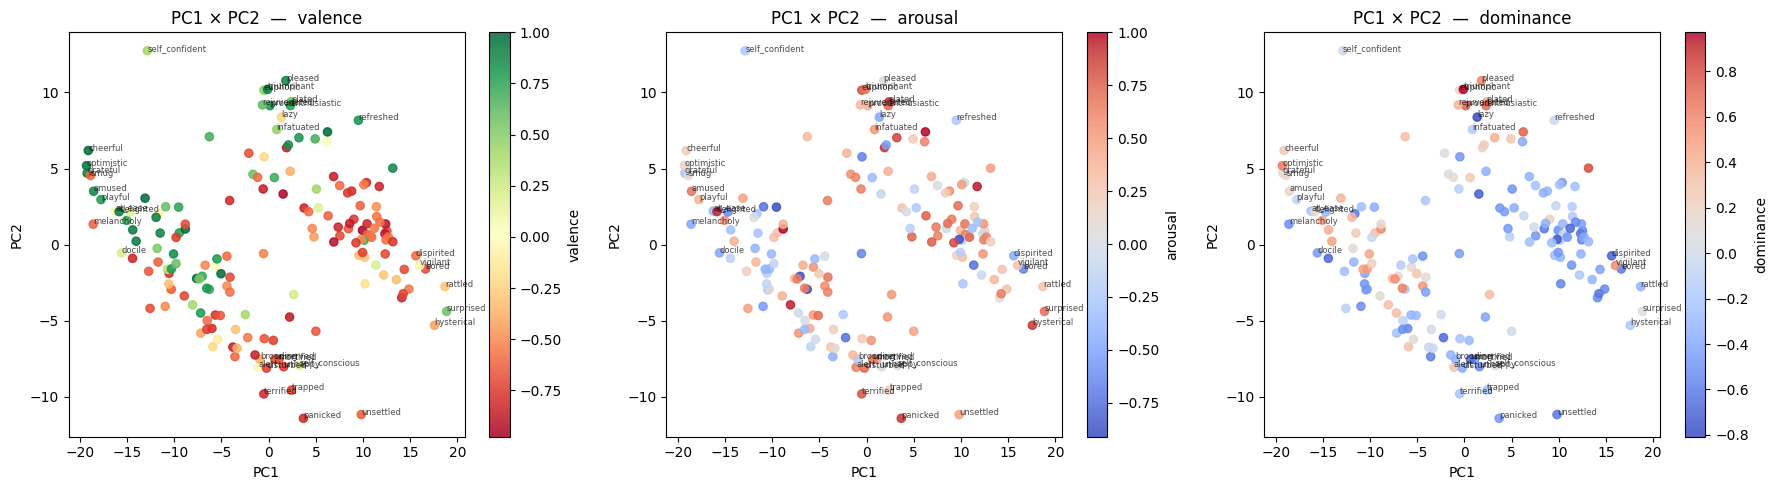

In [10]:
# ── Cell 9: Scatter plots — PC1×PC2 coloured by V, A, D ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (j, dim) in zip(axes, enumerate(dim_names)):
    sc = ax.scatter(scores[:, 0], scores[:, 1],
                    c=vad[:, j], cmap='RdYlGn' if dim == 'valence' else 'coolwarm',
                    s=35, alpha=0.85)
    plt.colorbar(sc, ax=ax, label=dim)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'PC1 × PC2  —  {dim}')
    thresh = 1.6 * scores[:, :2].std(axis=0)
    for name, s_row in zip(kept_names, scores):
        if abs(s_row[0]) > thresh[0] or abs(s_row[1]) > thresh[1]:
            ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)
plt.tight_layout()
plt.savefig('pc1pc2_vad.png', dpi=150)
plt.show()

In [11]:
# ── Cell 10: Compute per-emotion power scores ─────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

norms = np.linalg.norm(dirs, axis=1)                    # [N]
valence_extremity = np.abs(vad[:, 0] - 0.5)            # [N]  NRC valence is 0–1, neutral at 0.5

cos_matrix = cosine_similarity(dirs)                     # [N, N]
np.fill_diagonal(cos_matrix, -1)                         # ignore self
max_cosine = cos_matrix.max(axis=1)                      # [N] — nearest neighbour similarity

power = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))

# Summary: what drives power?
for name, n, v, mc, p in sorted(
        zip(kept_names, norms, valence_extremity, max_cosine, power),
        key=lambda x: -x[4])[:20]:
    print(f"{name:<30}  norm={n:.2f}  |v-0.5|={v:.3f}  max_cos={mc:.3f}  power={p:.2f}")


depressed                       norm=51.27  |v-0.5|=1.452  max_cos=0.974  power=76.41
heartbroken                     norm=49.57  |v-0.5|=1.336  max_cos=0.891  power=74.35
afraid                          norm=47.85  |v-0.5|=1.477  max_cos=0.971  power=72.81
furious                         norm=49.00  |v-0.5|=1.376  max_cos=0.958  power=70.36
tormented                       norm=50.28  |v-0.5|=1.358  max_cos=0.977  power=69.89
horrified                       norm=47.37  |v-0.5|=1.420  max_cos=0.965  power=69.74
miserable                       norm=49.19  |v-0.5|=1.376  max_cos=0.972  power=69.63
disgusted                       norm=48.40  |v-0.5|=1.398  max_cos=0.973  power=69.55
grief_stricken                  norm=47.41  |v-0.5|=1.360  max_cos=0.936  power=68.88
frustrated                      norm=48.96  |v-0.5|=1.340  max_cos=0.953  power=68.85
hurt                            norm=48.82  |v-0.5|=1.376  max_cos=0.980  power=68.55
worried                         norm=50.53  |v-0.5|=1.

In [12]:
# ── Cell 11: Select top-N per valence pole ────────────────────────────────────
def select_emotional_range(kept_names, dirs, vad, power, n_per_pole=15):
    pos_mask = vad[:, 0] > 0.5   # positive valence
    neg_mask = vad[:, 0] < 0.5   # negative valence

    def top_n(mask, n):
        idx = np.where(mask)[0]
        ranked = sorted(idx, key=lambda i: -power[i])
        return ranked[:n]

    pos_idx = top_n(pos_mask, n_per_pole)
    neg_idx = top_n(neg_mask, n_per_pole)
    selected = pos_idx + neg_idx

    print(f"\nPositive pole ({n_per_pole}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")
    print(f"\nNegative pole ({n_per_pole}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")

    return selected

selected_idx = select_emotional_range(kept_names, dirs, vad, power, n_per_pole=15)


Positive pole (15):
  invigorated                     valence=1.000  power=25.74
  cheerful                        valence=0.990  power=24.96
  exuberant                       valence=1.000  power=24.78
  happy                           valence=0.985  power=24.52
  joyful                          valence=0.990  power=23.83
  empathetic                      valence=1.000  power=23.61
  optimistic                      valence=0.958  power=23.20
  grateful                        valence=0.916  power=22.39
  thankful                        valence=0.938  power=22.33
  delighted                       valence=0.938  power=21.56
  inspired                        valence=0.934  power=21.53
  triumphant                      valence=0.898  power=20.08
  satisfied                       valence=0.918  power=20.06
  hopeful                         valence=0.894  power=19.91
  pleased                         valence=0.878  power=19.64

Negative pole (15):
  depressed                       valence=-

In [13]:
# ── Cell 12: PCA and VAD correlations on emotional range subset ───────────────
def range_pca_analysis(selected_idx, n_pcs=10, label=""):
    sel_dirs = dirs[selected_idx]
    sel_vad  = vad[selected_idx]
    sel_names = [kept_names[i] for i in selected_idx]
    N_sel = len(selected_idx)

    pca_r = PCA(n_components=min(n_pcs, N_sel))
    scores_r = pca_r.fit_transform(sel_dirs)

    print(f"\n── {label} (N={N_sel}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(min(n_pcs, N_sel)):
        rv, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_r.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # Cumulative R² for valence
    cum_r2_v = sum(stats.pearsonr(scores_r[:, i], sel_vad[:, 0])[0]**2
                   for i in range(min(5, N_sel)))
    print(f"\n  Valence R² (top-5 PCs combined): {cum_r2_v:.3f}  → r={cum_r2_v**0.5:.3f}")
    return pca_r, scores_r, sel_names

# Try different N values
for n in [10, 15, 20]:
    idx = select_emotional_range(kept_names, dirs, vad, power, n_per_pole=n)
    range_pca_analysis(idx, label=f"Top-{n} per pole")


Positive pole (10):
  invigorated                     valence=1.000  power=25.74
  cheerful                        valence=0.990  power=24.96
  exuberant                       valence=1.000  power=24.78
  happy                           valence=0.985  power=24.52
  joyful                          valence=0.990  power=23.83
  empathetic                      valence=1.000  power=23.61
  optimistic                      valence=0.958  power=23.20
  grateful                        valence=0.916  power=22.39
  thankful                        valence=0.938  power=22.33
  delighted                       valence=0.938  power=21.56

Negative pole (10):
  depressed                       valence=-0.952  power=76.41
  heartbroken                     valence=-0.836  power=74.35
  afraid                          valence=-0.977  power=72.81
  furious                         valence=-0.876  power=70.36
  tormented                       valence=-0.858  power=69.89
  horrified                       vale

In [14]:
# ── Tri-polar selection ───────────────────────────────────────────────────────
# Requires: kept_names, dirs, vad, norms, max_cosine (all from Cells 3-10)
# NRC-VAD valence is in [-1, 1]; neutral ≈ 0

def select_tri_polar_emotions(kept_names, dirs, vad, norms, max_cosine,
                               n_per_pole=10, neutral_band=0.25):
    """
    Positive/negative poles: existing power score (consistent with Cell 10/11).
    Neutral pole: norm × distinctiveness, filtered to |valence| < neutral_band.
    """
    valence_extremity = np.abs(vad[:, 0] - 0.5)  # same formula as Cell 10
    power_full = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))
    neutral_power = norms * (1.0 / (max_cosine + 1e-6))  # no valence term

    pos_idx = np.where(vad[:, 0] > 0.5)[0]
    pos_idx = pos_idx[np.argsort(-power_full[pos_idx])][:n_per_pole]

    neg_idx = np.where(vad[:, 0] < -0.5)[0]  # symmetric: clearly negative
    neg_idx = neg_idx[np.argsort(-power_full[neg_idx])][:n_per_pole]

    neutral_idx = np.where(np.abs(vad[:, 0]) < neutral_band)[0]
    neutral_idx = neutral_idx[np.argsort(-neutral_power[neutral_idx])][:n_per_pole]

    print(f"\nPositive pole ({len(pos_idx)}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")
    print(f"\nNeutral pole ({len(neutral_idx)}, |v|<{neutral_band}):")
    for i in neutral_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  neutral_power={neutral_power[i]:.2f}")
    print(f"\nNegative pole ({len(neg_idx)}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")

    return {'positive': pos_idx.tolist(), 'neutral': neutral_idx.tolist(),
            'negative': neg_idx.tolist()}


def run_tripolar_pca(selected, kept_names, dirs, vad, n_pcs=5):
    pole_names = ['positive', 'neutral', 'negative']
    colours = {'positive': 'steelblue', 'negative': 'firebrick', 'neutral': 'goldenrod'}
    markers  = {'positive': '^', 'negative': 'v', 'neutral': 'o'}

    all_idx = selected['positive'] + selected['neutral'] + selected['negative']
    labels  = (
        ['positive'] * len(selected['positive']) +
        ['neutral']  * len(selected['neutral']) +
        ['negative'] * len(selected['negative'])
    )
    sel_dirs  = dirs[all_idx]
    sel_vad   = vad[all_idx]
    sel_names = [kept_names[i] for i in all_idx]

    pca_t    = PCA(n_components=min(n_pcs, len(all_idx)))
    scores_t = pca_t.fit_transform(sel_dirs)

    print(f"\n── Tri-polar PCA (N={len(all_idx)}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(pca_t.n_components_):
        rv, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_t.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # PC1×PC2 and PC2×PC3 — shape = pole, colour = arousal
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    arousals = sel_vad[:, 1]
    for ax, (xpc, ypc) in zip(axes, [(0, 1), (1, 2)]):
        for pole in pole_names:
            idx = [i for i, l in enumerate(labels) if l == pole]
            sc = ax.scatter(
                scores_t[idx, xpc], scores_t[idx, ypc],
                c=arousals[idx], cmap='RdYlBu_r', vmin=-1, vmax=1,
                marker=markers[pole], s=90, edgecolors=colours[pole],
                linewidths=1.5, label=pole, zorder=3,
            )
            for i in idx:
                ax.annotate(sel_names[i], (scores_t[i, xpc], scores_t[i, ypc]),
                            fontsize=7, alpha=0.75, ha='center', va='bottom')
        plt.colorbar(sc, ax=ax, label='Arousal')
        ax.set_xlabel(f'PC{xpc+1}'); ax.set_ylabel(f'PC{ypc+1}')
        ax.legend()
    axes[0].set_title('PC1 vs PC2 — shape=pole, colour=arousal')
    axes[1].set_title('PC2 vs PC3 — shape=pole, colour=arousal')
    plt.suptitle(f'Tri-polar emotional range — n={len(selected["positive"])} per pole', fontsize=12)
    plt.tight_layout()
    plt.savefig('tripolar_pca.png', dpi=150)
    plt.show()
    return scores_t, pca_t


Neutral band coverage (valence in [-1,1], neutral=0):
  |v|<0.15:   8 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.20:  12 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.25:  18 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.30:  20 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)

============================================================  n_per_pole=8

Positive pole (8):
  invigorated                     v=+1.000  power=25.74
  cheerful                        v=+0.990  power=24.96
  exuberant                       v=+1.000  power=24.78
  happy                           v=+0.985  power=24.52
  joyful                          v=+0.990  power=23.83
  empathetic                      v=+1.000  power=23.61
  optimistic      

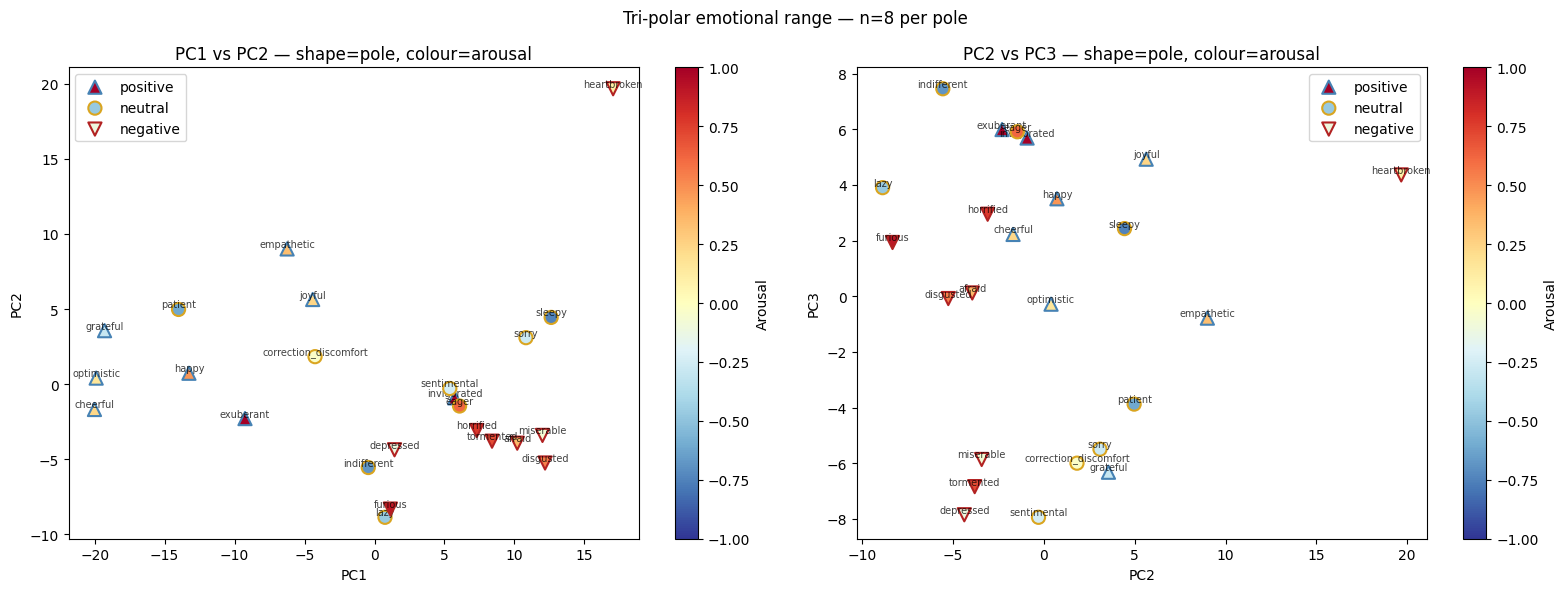


============================================================  n_per_pole=10

Positive pole (10):
  invigorated                     v=+1.000  power=25.74
  cheerful                        v=+0.990  power=24.96
  exuberant                       v=+1.000  power=24.78
  happy                           v=+0.985  power=24.52
  joyful                          v=+0.990  power=23.83
  empathetic                      v=+1.000  power=23.61
  optimistic                      v=+0.958  power=23.20
  grateful                        v=+0.916  power=22.39
  thankful                        v=+0.938  power=22.33
  delighted                       v=+0.938  power=21.56

Neutral pole (10, |v|<0.25):
  lazy                            v=-0.216  neutral_power=52.04
  sleepy                          v=+0.208  neutral_power=51.95
  indifferent                     v=-0.208  neutral_power=51.82
  patient                         v=+0.166  neutral_power=51.50
  sentimental                     v=+0.166  neutral_powe

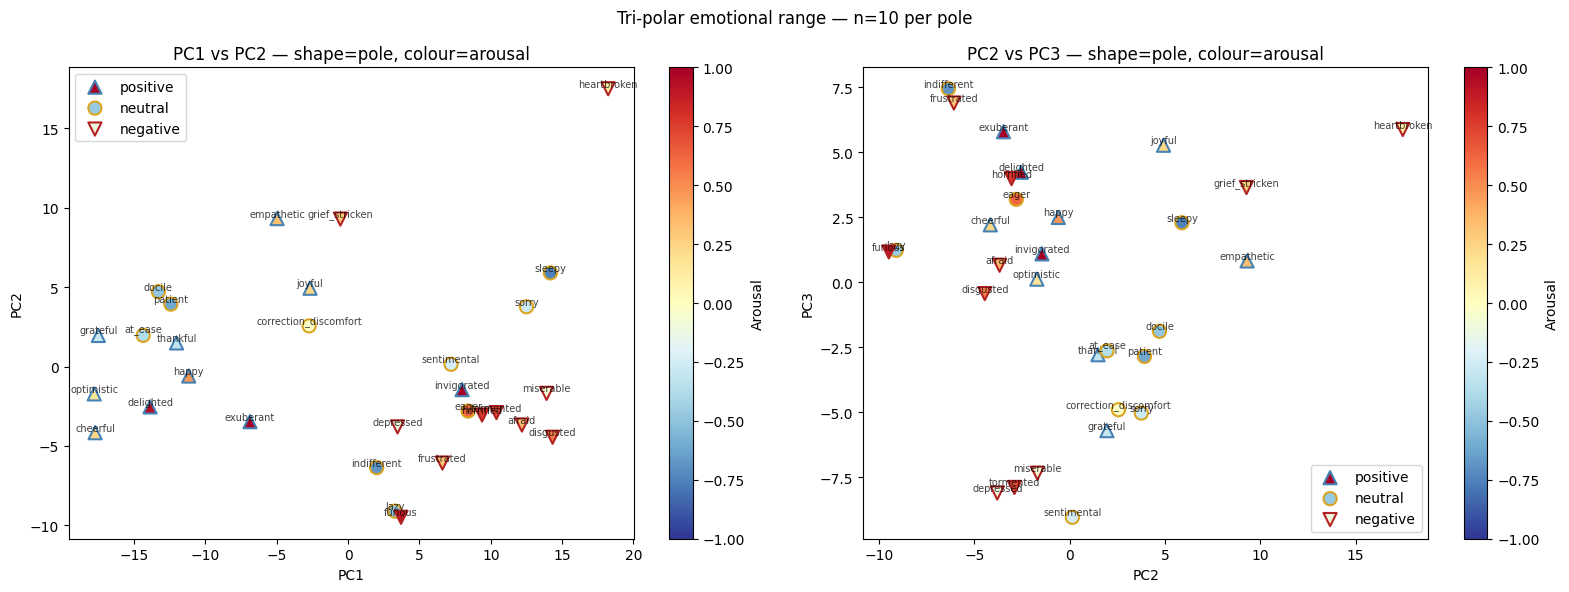


============================================================  n_per_pole=12

Positive pole (12):
  invigorated                     v=+1.000  power=25.74
  cheerful                        v=+0.990  power=24.96
  exuberant                       v=+1.000  power=24.78
  happy                           v=+0.985  power=24.52
  joyful                          v=+0.990  power=23.83
  empathetic                      v=+1.000  power=23.61
  optimistic                      v=+0.958  power=23.20
  grateful                        v=+0.916  power=22.39
  thankful                        v=+0.938  power=22.33
  delighted                       v=+0.938  power=21.56
  inspired                        v=+0.934  power=21.53
  triumphant                      v=+0.898  power=20.08

Neutral pole (12, |v|<0.25):
  lazy                            v=-0.216  neutral_power=52.04
  sleepy                          v=+0.208  neutral_power=51.95
  indifferent                     v=-0.208  neutral_power=51.82
  patien

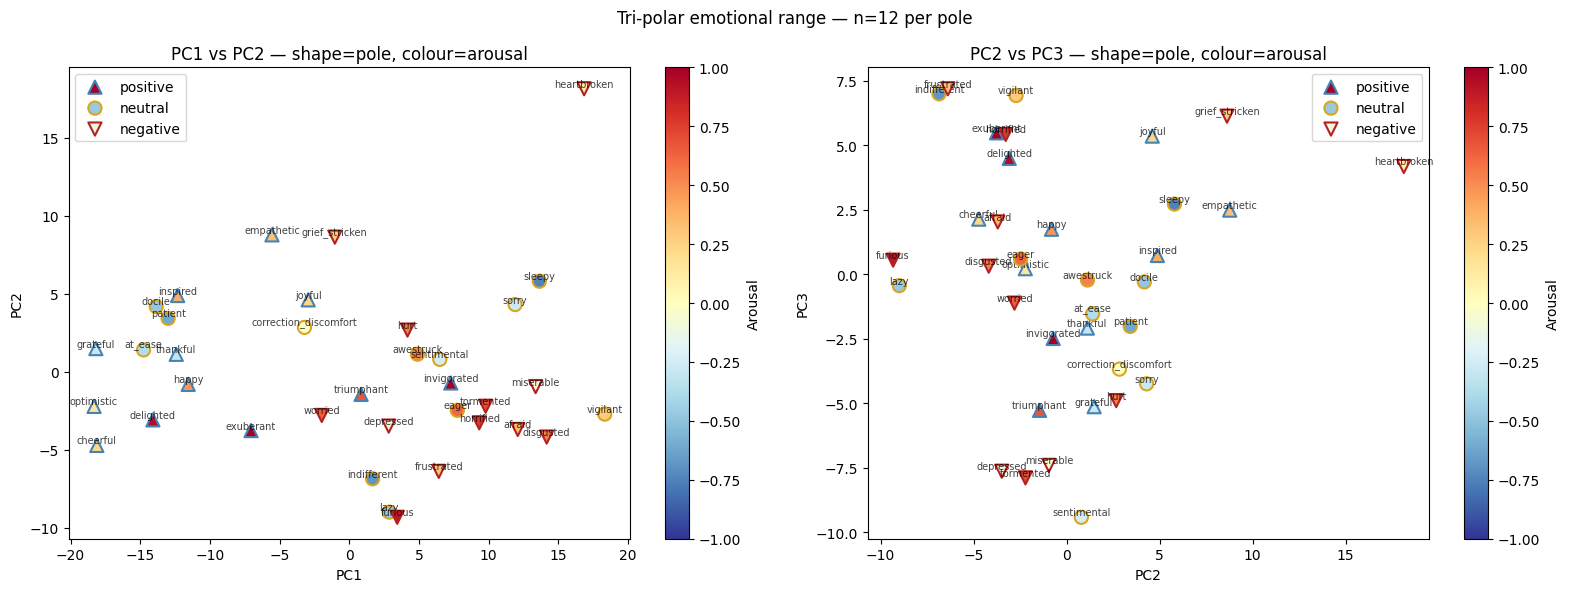

In [15]:
# ── Exercise ──────────────────────────────────────────────────────────────────

# First: check how many emotions fall in the neutral band at each threshold
print("Neutral band coverage (valence in [-1,1], neutral=0):")
for band in [0.15, 0.20, 0.25, 0.30]:
    in_band = [(kept_names[i], vad[i, 0]) for i in range(len(kept_names))
               if abs(vad[i, 0]) < band]
    preview = ', '.join(f"{n}({v:+.2f})" for n, v in
                        sorted(in_band, key=lambda x: abs(x[1]))[:6])
    print(f"  |v|<{band:.2f}: {len(in_band):3d} emotions — {preview}")

# Run at a few N values
for n in [8, 10, 12]:
    print(f"\n{'='*60}  n_per_pole={n}")
    selected = select_tri_polar_emotions(
        kept_names, dirs, vad, norms, max_cosine,
        n_per_pole=n, neutral_band=0.25,
    )
    run_tripolar_pca(selected, kept_names, dirs, vad)